<a href="https://colab.research.google.com/github/abdullah-al-bashit/TSS-2026/blob/main/Applied%20machine%20learning%20for%20biomedical%20data/ML_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session: Applied Machine Learning for Biomedical Data
### Workshop: Technical Skills Series (TSS)
· Dept. of Bioengineering, Northeastern University · April 10, 2026

---
**Goal:** Predict cancer type from gene expression using PyTorch.

**Dataset:** DepMap CCLE RNA-seq - 1400+ cancer cell lines, 19,000+ genes.

Run each cell with `Shift + Enter`.


In [1]:
# -- Install packages --
# Colab already has: torch, pandas, numpy, sklearn, seaborn
# Only install what's missing, without touching dependencies
!pip install -q captum --no-deps
!pip install -q shap --no-deps
!pip install -q slicer cloudpickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.7 MB/s eta 0:00:00


---
## Part A: Setup


In [2]:
# -- Imports (run after restart) --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


---
## Part B: Load and Explore

Upload `expression.csv` and `metadata.csv` to Colab (folder icon in sidebar).


In [3]:
# -- Load, merge, filter --
expr = pd.read_csv("expression.csv", index_col=0)
meta = pd.read_csv("metadata.csv")

# Keep only the columns we need, drop rows with missing cancer type
meta_slim = meta[["ModelID", "OncotreeLineage"]].dropna()

# Merge expression with metadata:
# left_index=True  -> use expression row index (ACH-000001 etc.) as join key
# right_on="ModelID" -> match against metadata's ModelID column
# .set_index(...)    -> put ModelID back as row index after merge
df = expr.merge(meta_slim, left_index=True, right_on="ModelID").set_index("ModelID")

# Count how many cell lines per cancer type
top_types = df["OncotreeLineage"].value_counts()
# Keep only cancer types with 50+ samples (too few = unreliable for ML with the current setting!)
keep = top_types[top_types >= 50].index.tolist()
# Filter: drop rare cancer types from the dataset
df = df[df["OncotreeLineage"].isin(keep)]

print(f"{expr.shape[0]} cell lines x {expr.shape[1]} genes")
print(f"After filter: {len(df)} cell lines, {len(keep)} cancer types\n")
print(top_types[top_types >= 50])

1517 cell lines x 19193 genes
After filter: 1086 cell lines, 12 cancer types

OncotreeLineage
Lung                    204
Lymphoid                166
CNS/Brain                97
Skin                     95
Bowel                    80
Esophagus/Stomach        73
Breast                   67
Ovary/Fallopian Tube     67
Head and Neck            65
Myeloid                  62
Soft Tissue              56
Pancreas                 54
Name: count, dtype: int64


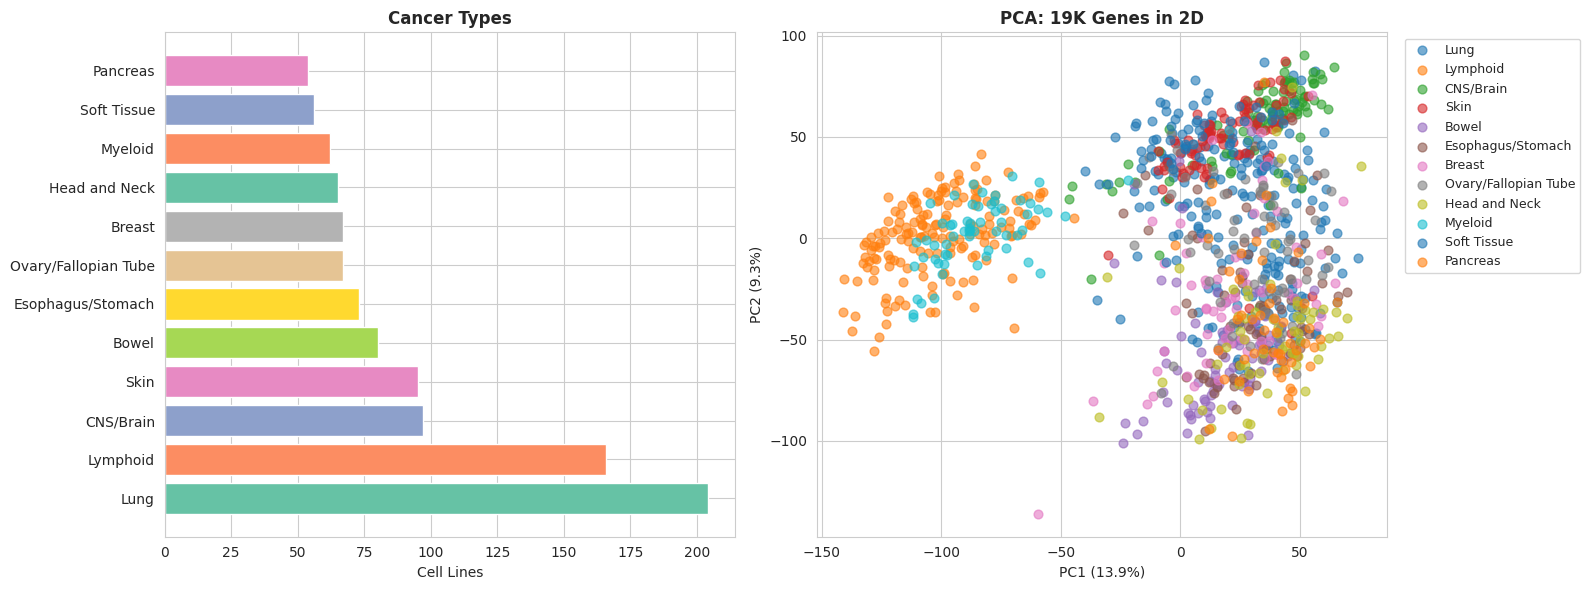

In [4]:
# -- Visualize: class distribution + PCA --
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

gene_cols = [c for c in df.columns if c != "OncotreeLineage"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts = df["OncotreeLineage"].value_counts()
axes[0].barh(counts.index, counts.values,
    color=sns.color_palette("Set2", len(counts)))
axes[0].set_xlabel("Cell Lines")
axes[0].set_title("Cancer Types", fontweight="bold")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[gene_cols].values)
for ct in keep:
    mask = df["OncotreeLineage"].values == ct
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=ct, alpha=0.6, s=40)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PCA: 19K Genes in 2D", fontweight="bold")
axes[1].legend(bbox_to_anchor=(1.02, 1), fontsize=9)
plt.tight_layout()
plt.show()

**Exercise:** Is this dataset balanced or imbalanced? Do cancer types separate in PCA?

Your answer:

&nbsp;


---
## Part C: Prepare Data

**Three-way split:**
- **Train (60%)** - model learns
- **Validation (20%)** - monitor overfitting, pick best epoch
- **Test (20%)** - final evaluation (only look once at the end)


In [5]:
# -- Feature selection + split + scale --
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
X_full = df[gene_cols].values
y = le.fit_transform(df["OncotreeLineage"].values)
n_classes = len(le.classes_)

# Use ALL genes - neural networks learn their own feature selection
X = X_full
selected_genes = gene_cols

# 60% train, 20% val, 20% test
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Class weights for imbalanced data
class_counts = np.bincount(y_train)   # Count samples per class in training set
class_weights = (1.0 / class_counts)  # Inverse frequency: rare classes get higher weight
class_weights = class_weights / class_weights.sum() * n_classes # Normalize so weights average to 1.0 (total weight = n_classes)

# Example: if Lung=150 samples, Skin=50 samples
#   class_counts  = [150, 50]     -> how many in each class
#   1/class_counts = [0.007, 0.02] -> rare class gets bigger number
#   after normalize = [0.5, 1.5]   -> Skin gets 3x more weight in loss

print(f"{len(gene_cols)} genes -> {X.shape[1]} selected")
print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print()
print(f"Class weights (from training set only):")
for i, name in enumerate(le.classes_):
    print(f"  {i} = {name:25s} n={class_counts[i]:3d}  weight={class_weights[i]:.2f}")

19193 genes -> 19193 selected
Train: 651  Val: 217  Test: 218

Class weights (from training set only):
  0 = Bowel                     n= 48  weight=0.96
  1 = Breast                    n= 40  weight=1.15
  2 = CNS/Brain                 n= 58  weight=0.80
  3 = Esophagus/Stomach         n= 44  weight=1.05
  4 = Head and Neck             n= 39  weight=1.18
  5 = Lung                      n=122  weight=0.38
  6 = Lymphoid                  n=100  weight=0.46
  7 = Myeloid                   n= 37  weight=1.25
  8 = Ovary/Fallopian Tube      n= 40  weight=1.15
  9 = Pancreas                  n= 32  weight=1.44
  10 = Skin                      n= 57  weight=0.81
  11 = Soft Tissue               n= 34  weight=1.36


**Exercise:** Exercise: Why three splits? What goes wrong if you train your model using full data?

Your answer:

&nbsp;


---
## Part D: Baseline - Simplest Possible Model


In [6]:
# -- Logistic Regression (simplest ML model) --
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_s, y_train)

print(f"Logistic Regression (simplest model):")
print(f"  Val:  {accuracy_score(y_val, lr.predict(X_val_s)):.1%}")
print(f"  Test: {accuracy_score(y_test, lr.predict(X_test_s)):.1%}")
print("\nCan a neural network beat this?")

Logistic Regression (simplest model):
  Val:  82.5%
  Test: 84.9%

Can a neural network beat this?


---
## Part E: PyTorch Neural Network

We start with a **tiny network** and compare it to Logistic Regression.
Then you will make it bigger to beat LR.

```
Step 1: 19K genes --> 32 --> cancer type       (tiny - can LR beat this?)
Step 2: YOU increase capacity to beat LR!
```


In [7]:
# -- Tensors --
X_train_t = torch.FloatTensor(X_train_s).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val_s).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test_s).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)
wt        = torch.FloatTensor(class_weights).to(device)
n_genes   = X_train_s.shape[1]

print(f"Input: {n_genes} genes -> Output: {n_classes} cancer types")

Input: 19193 genes -> Output: 12 cancer types


In [8]:
# -- Training helper (reusable) --
def train_and_evaluate(model, n_epochs=500, lr=0.001, batch_size=64, use_scheduler=False):
    dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    crit = nn.CrossEntropyLoss(weight=wt)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5) if use_scheduler else None
    hist = {"train": [], "val": []}
    best_val = 0.0
    best_state = None
    best_epoch = 0

    for epoch in range(n_epochs):
        model.train()
        correct = total = 0
        for xb, yb in dl:
            out = model(xb)
            loss = crit(out, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)

        model.eval()
        with torch.no_grad():
            vacc = (model(X_val_t).argmax(1) == y_val_t).float().mean().item()

        hist["train"].append(correct / total)
        hist["val"].append(vacc)

        # Scheduler: reduce learning rate when val accuracy stops improving
        # (1-vacc) converts accuracy to a loss-like metric that scheduler expects to decrease
        if sched:
            sched.step(1 - vacc)

        if vacc > best_val:
            best_val = vacc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1

        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train: {hist['train'][-1]:.1%} | "
                  f"Val: {vacc:.1%} | "
                  f"Gap: {hist['train'][-1]-vacc:.1%}")

    model.load_state_dict(best_state)
    print(f"  Best: epoch {best_epoch}, val {best_val:.1%}")
    return hist, best_epoch, best_val

print("Training helper ready.")

Training helper ready.


### Step 1: Tiny Model


In [9]:
# -- Tiny model: single hidden layer of 32 --
class TinyNet(nn.Module):
    def __init__(self, n_genes, n_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_genes, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.network(x)

tiny_model = TinyNet(n_genes, n_classes).to(device)
print(tiny_model)
print(f"Parameters: {sum(p.numel() for p in tiny_model.parameters()):,}")
print("\nVery small - can it even beat Logistic Regression?")

TinyNet(
  (network): Sequential(
    (0): Linear(in_features=19193, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
)
Parameters: 614,604

Very small - can it even beat Logistic Regression?


In [10]:
# -- Train tiny model --
print("Training tiny model (19K -> 32 -> classes)...\n")
tiny_hist, tiny_best, tiny_val = train_and_evaluate(tiny_model, n_epochs=300, lr=0.001, use_scheduler=False)

Training tiny model (19K -> 32 -> classes)...

  Epoch  50/300 | Train: 100.0% | Val: 79.7% | Gap: 20.3%
  Epoch 100/300 | Train: 100.0% | Val: 79.7% | Gap: 20.3%
  Epoch 150/300 | Train: 100.0% | Val: 79.7% | Gap: 20.3%
  Epoch 200/300 | Train: 100.0% | Val: 79.7% | Gap: 20.3%
  Epoch 250/300 | Train: 100.0% | Val: 80.6% | Gap: 19.4%
  Epoch 300/300 | Train: 100.0% | Val: 80.6% | Gap: 19.4%
  Best: epoch 224, val 80.6%


In [11]:
# -- Compare tiny NN vs LR --
tiny_model.eval()
with torch.no_grad():
    tiny_test = accuracy_score(y_test, tiny_model(X_test_t).argmax(1).cpu().numpy())

print(f"Logistic Regression: val {accuracy_score(y_val, lr.predict(X_val_s)):.1%}, test {accuracy_score(y_test, lr.predict(X_test_s)):.1%}")
print(f"Tiny NN (32 neurons): val {tiny_val:.1%}, test {tiny_test:.1%}")
print(f"\n{'LR wins!' if accuracy_score(y_test, lr.predict(X_test_s)) > tiny_test else 'NN wins!'}")
print("\nThe tiny network doesn't have enough capacity to learn complex patterns.")
print("Can you make it bigger to beat LR?")

Logistic Regression: val 82.5%, test 84.9%
Tiny NN (32 neurons): val 80.6%, test 81.2%

LR wins!

The tiny network doesn't have enough capacity to learn complex patterns.
Can you make it bigger to beat LR?


### Step 2: Your Turn - Increase Model Capacity!

The tiny model (32 neurons) lost to simple Logistic Regression.
Make it bigger! Try:
- More neurons per layer (64, 128)
- More layers (add a second hidden layer)
- Add `nn.BatchNorm1d()` to normalize the noisy 19K input
- Add `nn.Dropout()` to prevent memorization
- Use a learning rate scheduler to fine-tune in later epochs

Modify the network below and re-train:


In [12]:
# -- YOUR CODE HERE: Build a better model --
class CancerNet(nn.Module):
    def __init__(self, n_genes, n_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_genes, 256),         # YOUR CODE HERE: try 128, 256, 512 etc.
            nn.BatchNorm1d(256),             # YOUR CODE HERE: add BatchNorm (must be the same number as before) e.g. nn.BatchNorm1d(256) after nn.Linear(n_genes, 256)
            nn.ReLU(),
            nn.Dropout(0.5),                 # YOUR CODE HERE: change Dropout e.g. nn.Dropout(0.3)

            nn.Linear(256, 128),             # YOUR CODE HERE: second layer (e.g. nn.Linear(256, 128) first parameter 256 is same as before nn.BatchNorm1d(256))
            nn.BatchNorm1d(128),             # BatchNorm
            nn.ReLU(),
            # nn.Dropout(0.3) = randomly turn off 30% of neurons each training step
            # Example: if layer has 128 neurons, ~38 random neurons output 0 each batch
            # Why: forces the network to not rely on any single neuron
            #      = learns redundant, robust patterns instead of memorizing
            # Note: only active during training (model.train())
            #       automatically disabled during evaluation (model.eval())
            nn.Dropout(0.3),                 # Dropout

            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.network(x)

model = CancerNet(n_genes, n_classes).to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\nBatchNorm normalizes the noisy 19K input, Dropout prevents memorizing")

CancerNet(
  (network): Sequential(
    (0): Linear(in_features=19193, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=12, bias=True)
  )
)
Parameters: 4,948,876

BatchNorm normalizes the noisy 19K input, Dropout prevents memorizing


---
**Exercise:** How many parameters does your model have? Try changing the first layer from 256 to 128:
```
nn.Linear(n_genes, 128),   instead of   nn.Linear(n_genes, 256)
nn.BatchNorm1d(128),       instead of   nn.BatchNorm1d(256)
nn.ReLU(),
nn.Dropout(0.5),
nn.Linear(128, 128)       instead of   nn.Linear(256, 128)
```

Re-run the cell. How did the parameter count change? Why?

Your answer:



**Hint:** `nn.Linear(A, B)` has `A * B + B` parameters (weights + biases). So `nn.Linear(19193, 256)` = 19193 * 256 + 256 = 4,913,664. `nn.BatchNorm1d(256)` adds only 512 (2 per neuron: scale + shift). Dropout adds 0 parameters (it's just a mask).

In [13]:
# -- Train your bigger model --
print("Training your model...\n")
hist, best_epoch, best_val = train_and_evaluate(model, n_epochs=500, lr=0.0005, use_scheduler=True)

Training your model...

  Epoch  50/500 | Train: 100.0% | Val: 82.0% | Gap: 18.0%
  Epoch 100/500 | Train: 99.8% | Val: 82.9% | Gap: 16.9%
  Epoch 150/500 | Train: 100.0% | Val: 82.5% | Gap: 17.5%
  Epoch 200/500 | Train: 100.0% | Val: 83.9% | Gap: 16.1%
  Epoch 250/500 | Train: 100.0% | Val: 83.4% | Gap: 16.6%
  Epoch 300/500 | Train: 100.0% | Val: 82.9% | Gap: 17.1%
  Epoch 350/500 | Train: 100.0% | Val: 82.9% | Gap: 17.1%
  Epoch 400/500 | Train: 100.0% | Val: 82.9% | Gap: 17.1%
  Epoch 450/500 | Train: 100.0% | Val: 82.5% | Gap: 17.5%
  Epoch 500/500 | Train: 100.0% | Val: 83.4% | Gap: 16.6%
  Best: epoch 16, val 84.8%


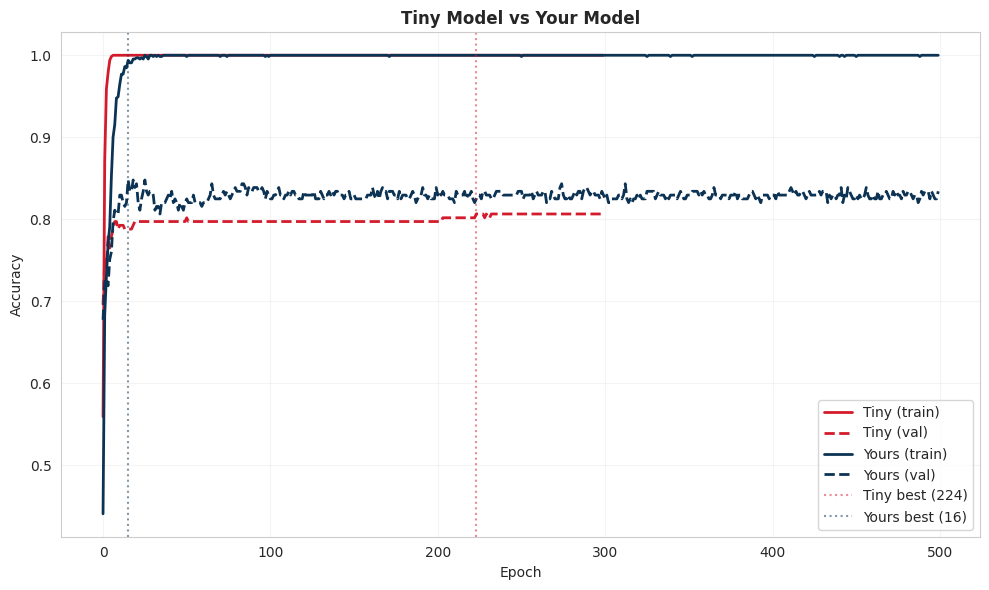

Tiny:  best epoch 224, val 80.6%
Yours: best epoch 16, val 84.8%


In [14]:
# -- Training curves: tiny vs your model --
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tiny_hist["train"], label="Tiny (train)", color="#D41B2C", linewidth=2)
ax.plot(tiny_hist["val"], label="Tiny (val)", color="#D41B2C", linewidth=2, linestyle="--")
ax.plot(hist["train"], label="Yours (train)", color="#0C3354", linewidth=2)
ax.plot(hist["val"], label="Yours (val)", color="#0C3354", linewidth=2, linestyle="--")
ax.axvline(x=tiny_best-1, color="#D41B2C", linestyle=":", alpha=0.5, label=f"Tiny best ({tiny_best})")
ax.axvline(x=best_epoch-1, color="#0C3354", linestyle=":", alpha=0.5, label=f"Yours best ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Tiny Model vs Your Model", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Tiny:  best epoch {tiny_best}, val {tiny_val:.1%}")
print(f"Yours: best epoch {best_epoch}, val {best_val:.1%}")

**Exercise:** Compare the two training curves. Which model overfits more? Which has better val accuracy?

Your answer:

&nbsp;


In [15]:
# -- Evaluate on TEST set (your bigger model- CancerNet!) --
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_t).argmax(1).cpu().numpy()
    probs = torch.softmax(model(X_test_t), dim=1).cpu().numpy()

acc_nn = accuracy_score(y_test, y_pred_nn)
print(f"Your model - Test accuracy: {acc_nn:.1%}")
print(f"\nPer-class:")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))

Your model - Test accuracy: 85.8%

Per-class:
                      precision    recall  f1-score   support

               Bowel       0.94      0.94      0.94        16
              Breast       0.85      0.79      0.81        14
           CNS/Brain       0.75      0.90      0.82        20
   Esophagus/Stomach       0.80      0.53      0.64        15
       Head and Neck       0.79      0.85      0.81        13
                Lung       0.90      0.85      0.88        41
            Lymphoid       0.97      1.00      0.99        33
             Myeloid       1.00      0.92      0.96        12
Ovary/Fallopian Tube       0.78      0.54      0.64        13
            Pancreas       0.65      1.00      0.79        11
                Skin       0.90      1.00      0.95        19
         Soft Tissue       0.80      0.73      0.76        11

            accuracy                           0.86       218
           macro avg       0.84      0.84      0.83       218
        weighted avg  

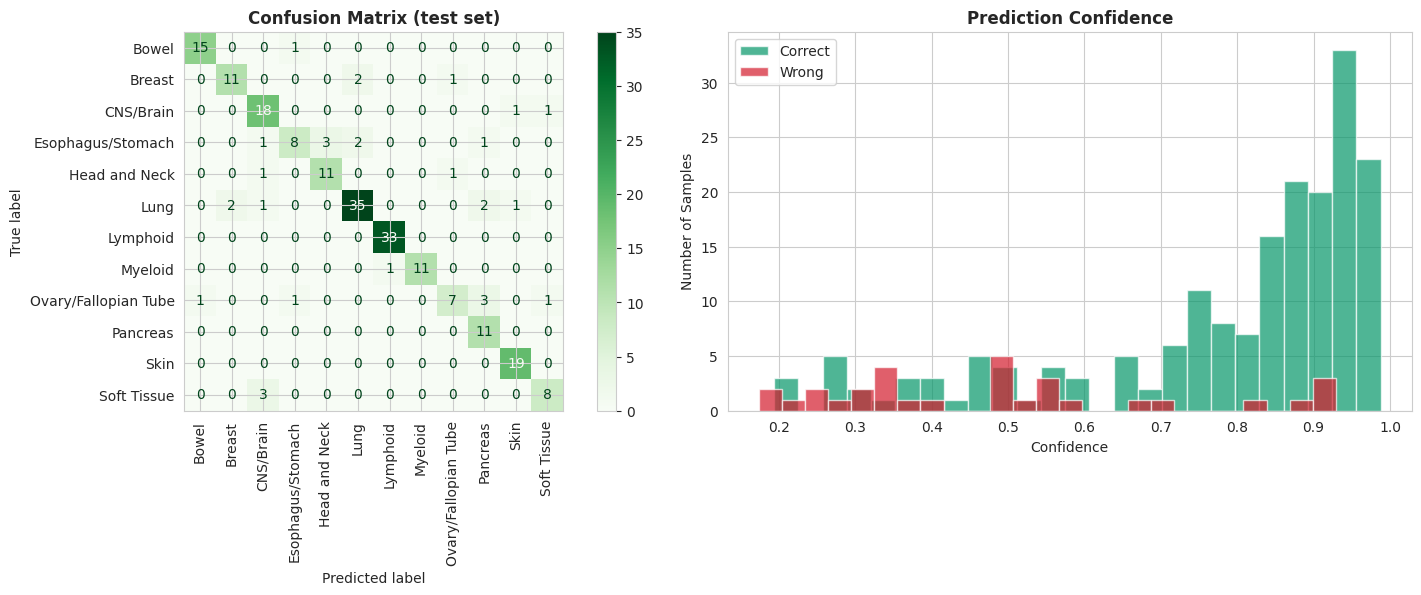

Avg confidence (correct): 78.7%
Avg confidence (wrong):   49.1%


In [16]:
# -- Confusion matrix + confidence --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nn),
    display_labels=le.classes_).plot(ax=axes[0], cmap="Greens", values_format="d")
axes[0].set_title("Confusion Matrix (test set)", fontweight="bold")
axes[0].tick_params(axis='x', rotation=90)

# Confidence plot: does the model "know what it doesn't know"?
# max_probs = highest probability the model assigned to any class
#   e.g., [Lung=0.92, Breast=0.05, Skin=0.03] -> max = 0.92 (very confident)
#   e.g., [Lung=0.40, Breast=0.35, Skin=0.25] -> max = 0.40 (uncertain)
max_probs = probs.max(axis=1)
correct = y_test == y_pred_nn
# Green bars = confidence on samples it got RIGHT (ideally near 1.0)
axes[1].hist(max_probs[correct], bins=25, alpha=0.7, color="#059669", label="Correct")
# Red bars = confidence on samples it got WRONG (ideally lower)
# If green is high and red is low -> model knows when to trust itself
axes[1].hist(max_probs[~correct], bins=25, alpha=0.7, color="#D41B2C", label="Wrong")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Prediction Confidence", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Avg confidence (correct): {max_probs[correct].mean():.1%}")
print(f"Avg confidence (wrong):   {max_probs[~correct].mean():.1%}")

**Exercise:** What does prediction confidence plot mean? How could a doctor use the confidence score?

Your answer:

&nbsp;


---
## Part F: Compare


                  Model   Val  Test
    Logistic Regression 0.825 0.849
Tiny NN (32, epoch 224) 0.806 0.812
     Your NN (epoch 16) 0.848 0.858


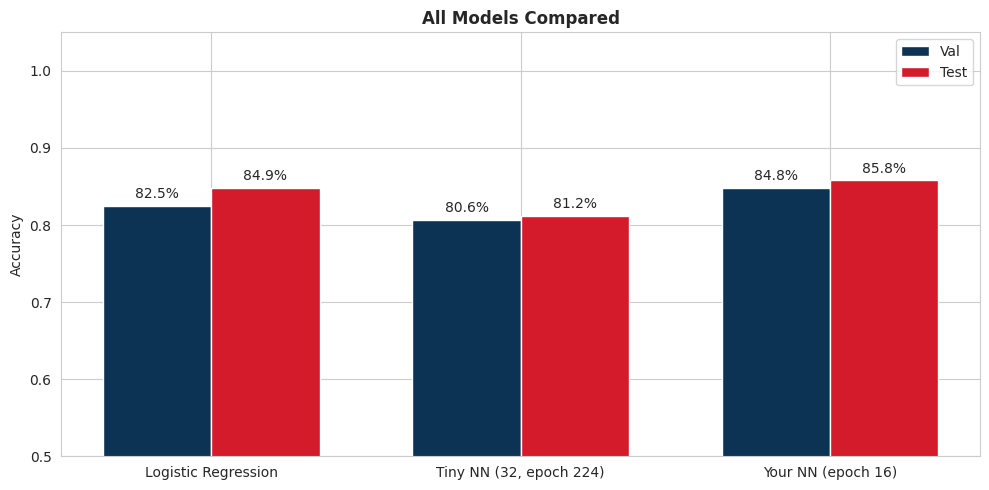


Your NN beat LR by 0.9%!


In [17]:
# -- All 3 models compared --
y_pred_lr = lr.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)

results = pd.DataFrame({
    "Model": ["Logistic Regression", f"Tiny NN (32, epoch {tiny_best})", f"Your NN (epoch {best_epoch})"],
    "Val": [accuracy_score(y_val, lr.predict(X_val_s)), tiny_val, best_val],
    "Test": [acc_lr, tiny_test, acc_nn],
})
print(results.round(3).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results))
w = 0.35
for bars, col, key in [
    ([i-w/2 for i in x], "#0C3354", "Val"),
    ([i+w/2 for i in x], "#D41B2C", "Test")]:
    b = ax.bar(bars, results[key], w, label=key, color=col)
    for bar in b:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.1%}", ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_title("All Models Compared", fontweight="bold")
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

if acc_nn > acc_lr:
    print(f"\nYour NN beat LR by {acc_nn - acc_lr:.1%}!")
else:
    print(f"\nLR still wins by {acc_lr - acc_nn:.1%}. Try a bigger network!")

**Exercise:** Did your NN beat Logistic Regression? What was the key change that helped?

Your answer:

&nbsp;


---
## Part G: Which Genes Matter?


In [18]:
# -- Feature Importance: 4 methods compared --
# 1. LR Weights        - linear coefficient per gene (instant)
# 2. NN Vanilla Grads  - gradient at class mean input (fast, noisy)
# 3. Captum IG         - accumulated gradient from zero to input (stable)
# 4. SHAP Deep         - game-theory attribution (gold standard)


from captum.attr import IntegratedGradients
import shap

model.eval()
gene_names = [g.split(" ")[0] for g in selected_genes]

# -- Compute all 4 attributions for each class (store in dict) --
# Each entry: {method_name: {cancer_name: pd.Series of gene importances}}

methods = {}

# Shared: average input per class + baseline
class_means = {}
for cls_idx in range(min(6, n_classes)):
    mask = y_train == cls_idx
    class_means[cls_idx] = torch.FloatTensor(X_train_s[mask].mean(axis=0)).unsqueeze(0).to(device)

baseline = torch.zeros(1, n_genes).to(device)

# 1. LR Weights: lr.coef_ shape (n_classes, n_genes)
methods["LR Weights"] = {}
for cls_idx, cancer in enumerate(le.classes_):
    if cls_idx >= 6: break
    methods["LR Weights"][cancer] = pd.Series(lr.coef_[cls_idx], index=gene_names)

# 2. NN Vanilla Gradients: d(output[class]) / d(input) at class mean
methods["NN Gradients"] = {}
for cls_idx, cancer in enumerate(le.classes_):
    if cls_idx >= 6: break
    x = class_means[cls_idx].clone().requires_grad_(True)
    out = model(x)
    out[0, cls_idx].backward()
    methods["NN Gradients"][cancer] = pd.Series(x.grad[0].cpu().numpy(), index=gene_names)

# 3. Captum Integrated Gradients: accumulated along path from zero to input
ig = IntegratedGradients(model)
methods["Captum IG"] = {}
for cls_idx, cancer in enumerate(le.classes_):
    if cls_idx >= 6: break
    attr = ig.attribute(class_means[cls_idx], baselines=baseline, target=cls_idx, n_steps=50)
    methods["Captum IG"][cancer] = pd.Series(attr[0].cpu().detach().numpy(), index=gene_names)

# 4. SHAP DeepExplainer: game-theory based, compared against background samples
bg_idx = np.random.choice(len(X_train_s), 100, replace=False)
background = torch.FloatTensor(X_train_s[bg_idx]).to(device)
explainer = shap.DeepExplainer(model, background)
methods["SHAP Deep"] = {}
for cls_idx, cancer in enumerate(le.classes_):
    if cls_idx >= 6: break
    shap_vals = explainer.shap_values(class_means[cls_idx])
    if isinstance(shap_vals, list):
        sv = shap_vals[cls_idx][0]
    elif hasattr(shap_vals, 'ndim') and shap_vals.ndim == 3:
        sv = shap_vals[0, :, cls_idx]
    else:
        sv = shap_vals[0]
    methods["SHAP Deep"][cancer] = pd.Series(sv, index=gene_names)

print(f"Computed 4 methods x {min(6, n_classes)} cancer types")

Computed 4 methods x 6 cancer types


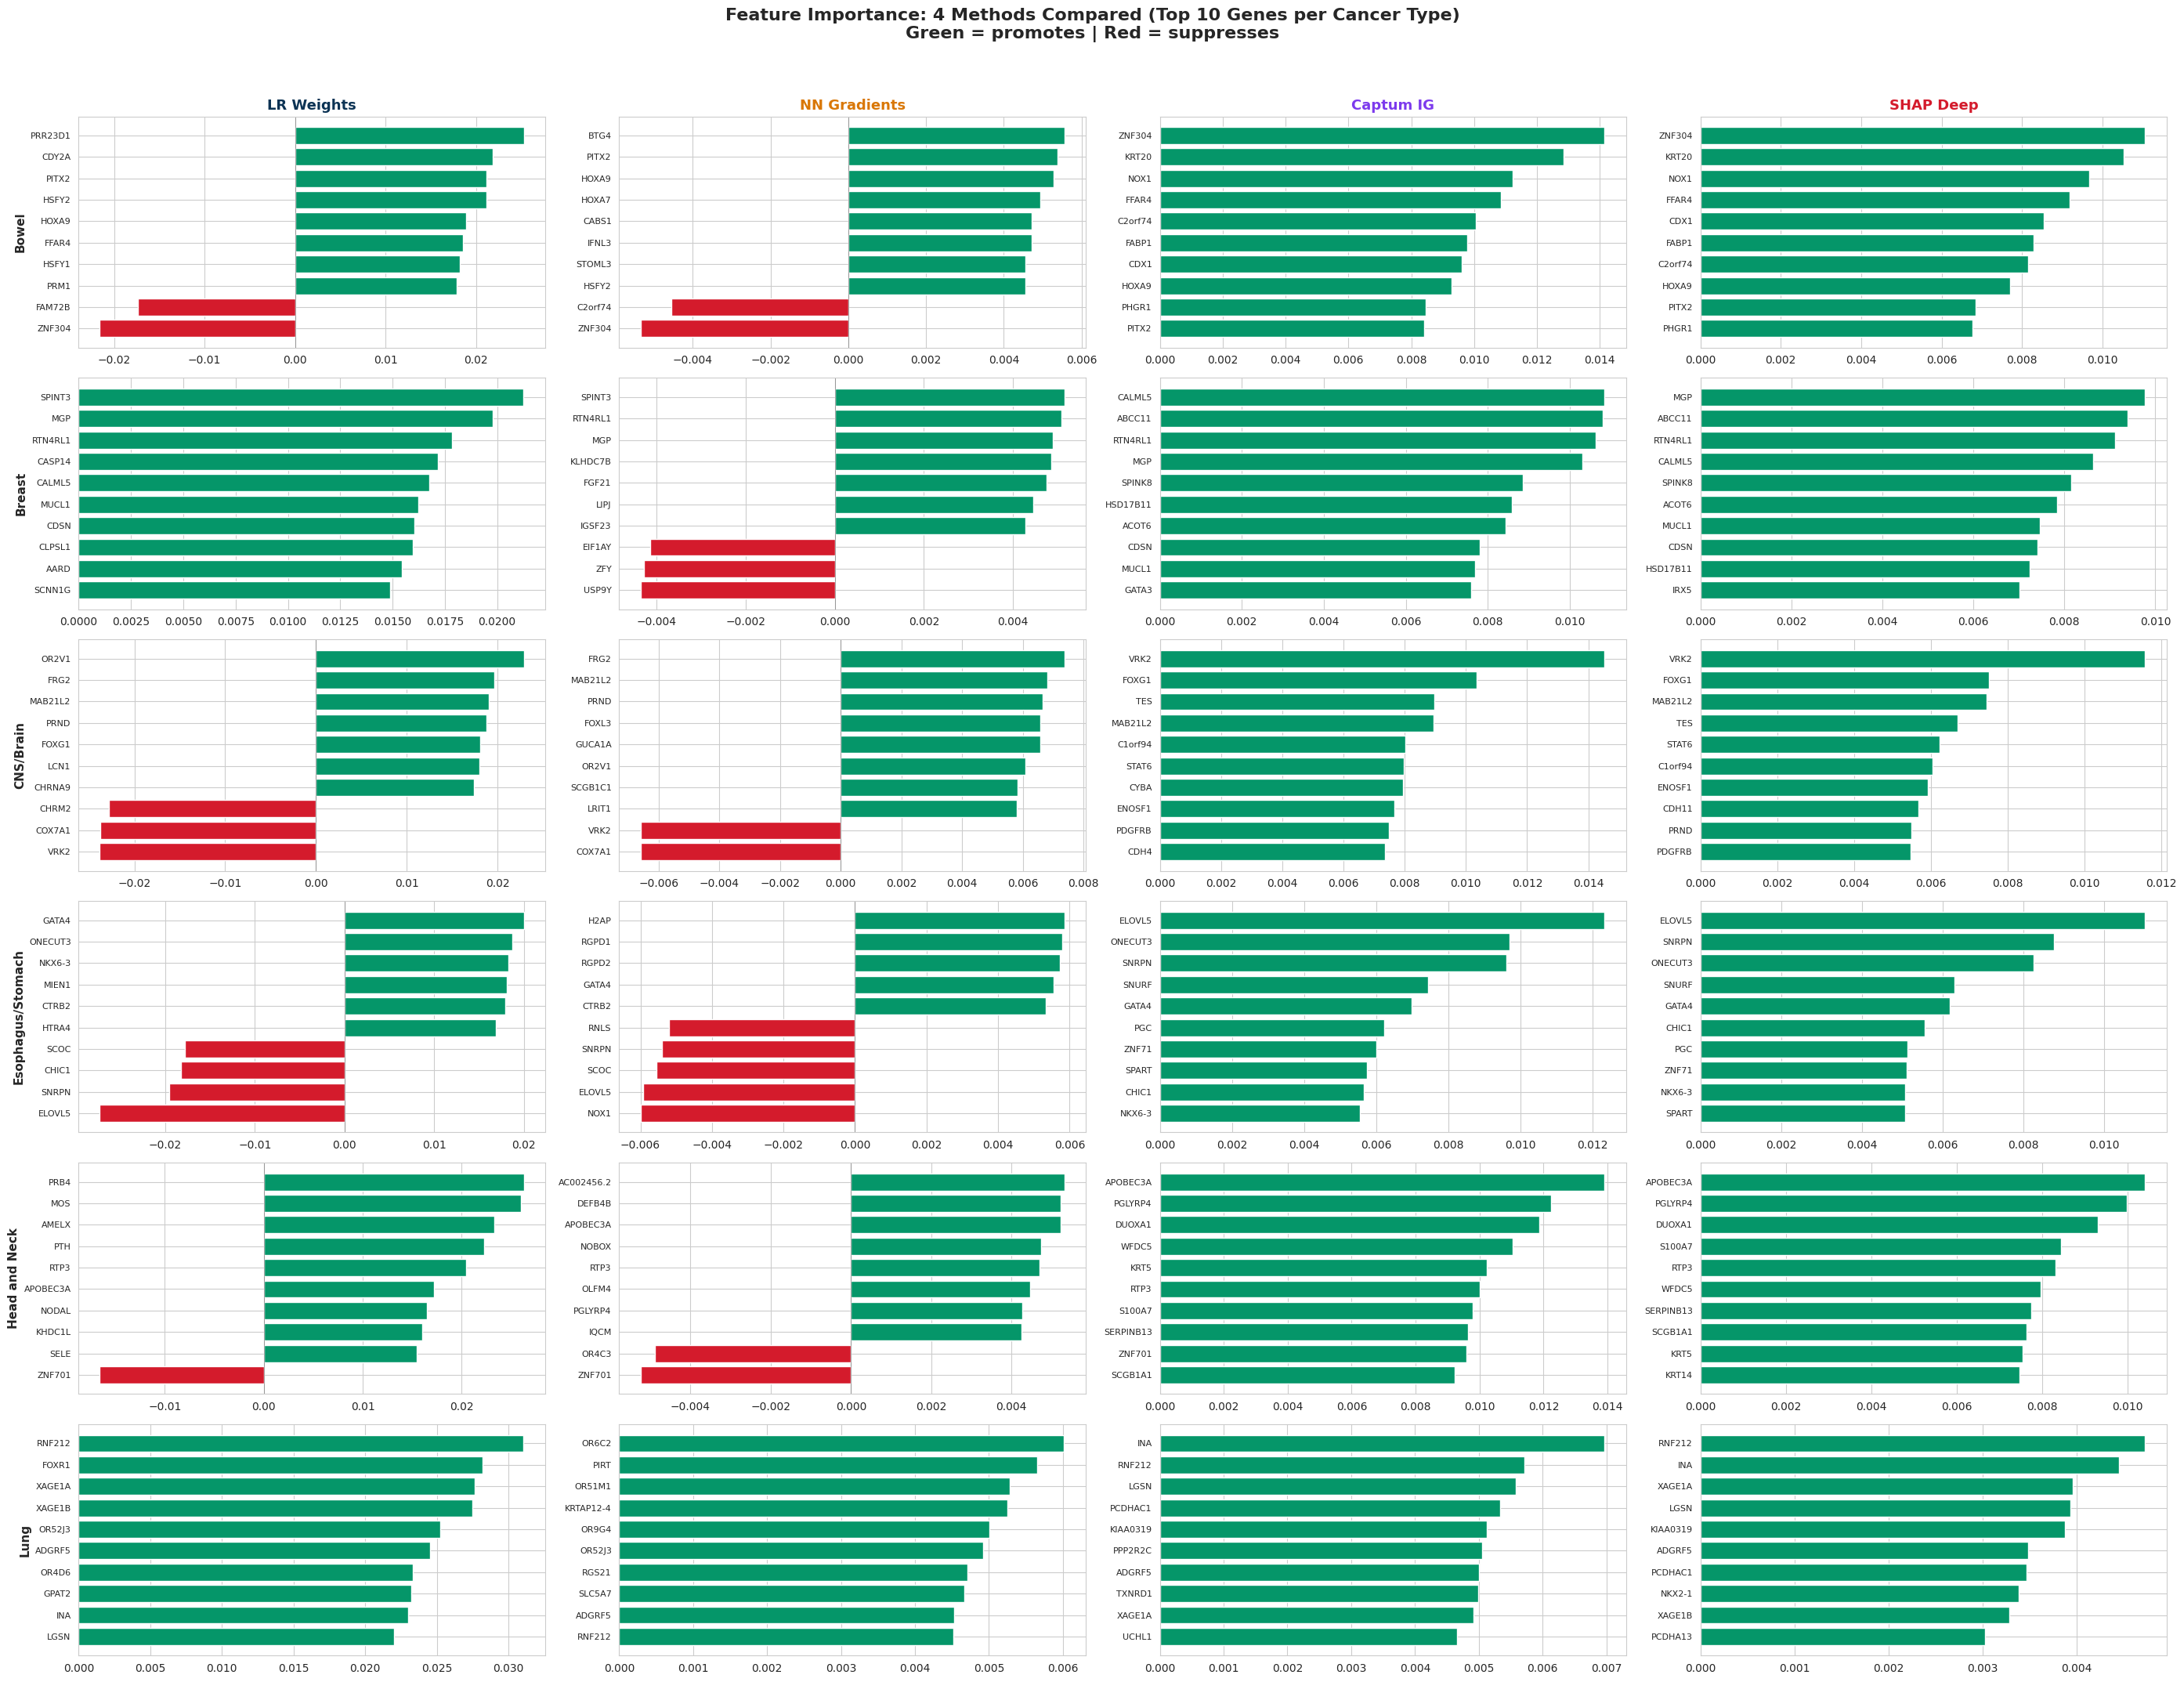

In [19]:
# -- All 4 methods in one plot --
# Rows = cancer types, Columns = methods
# Green = promotes this cancer | Red = suppresses

method_names = list(methods.keys())
cancers = list(methods[method_names[0]].keys())
n_cancers = len(cancers)

fig, axes = plt.subplots(n_cancers, 4, figsize=(28, n_cancers * 3.5))
method_colors = {"LR Weights": "#0C3354", "NN Gradients": "#D97706",
                 "Captum IG": "#7C3AED", "SHAP Deep": "#D41B2C"}

for row, cancer in enumerate(cancers):
    for col, method in enumerate(method_names):
        imp = methods[method][cancer]
        top10 = imp.abs().sort_values(ascending=False).head(10)
        top_vals = imp[top10.index].sort_values()
        colors = ["#D41B2C" if v < 0 else "#059669" for v in top_vals.values]

        ax = axes[row, col]
        ax.barh(top_vals.index, top_vals.values, color=colors)
        ax.axvline(x=0, color="gray", linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)

        if row == 0:
            ax.set_title(method, fontweight="bold", color=method_colors[method], fontsize=13)
        if col == 0:
            ax.set_ylabel(cancer, fontweight="bold", fontsize=11)

plt.suptitle("Feature Importance: 4 Methods Compared (Top 10 Genes per Cancer Type)\n"
             "Green = promotes | Red = suppresses",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# -- Summary: how much do the 4 methods agree? --
# For each cancer type, count how many top-10 genes are shared between method pairs

print("Gene overlap (out of 10) between methods per cancer type:\n")
print(f"{'Cancer':25s} {'LR-Grad':>8} {'LR-IG':>8} {'LR-SHAP':>8} {'Grad-IG':>8} {'Grad-SHAP':>10} {'IG-SHAP':>8} {'All 4':>8}")
print("-" * 105)

for cancer in cancers:
    tops = {}
    for method in method_names:
        tops[method] = set(methods[method][cancer].abs().sort_values(ascending=False).head(10).index)

    lr_g  = len(tops["LR Weights"] & tops["NN Gradients"])
    lr_ig = len(tops["LR Weights"] & tops["Captum IG"])
    lr_sh = len(tops["LR Weights"] & tops["SHAP Deep"])
    g_ig  = len(tops["NN Gradients"] & tops["Captum IG"])
    g_sh  = len(tops["NN Gradients"] & tops["SHAP Deep"])
    ig_sh = len(tops["Captum IG"] & tops["SHAP Deep"])
    all4  = len(tops["LR Weights"] & tops["NN Gradients"] & tops["Captum IG"] & tops["SHAP Deep"])

    print(f"{cancer:25s} {lr_g:>8} {lr_ig:>8} {lr_sh:>8} {g_ig:>8} {g_sh:>10} {ig_sh:>8} {all4:>8}")

# Genes all 4 methods agree on
print(f"\nGenes ALL 4 methods agree on (strongest biological signals):")
for cancer in cancers:
    shared = set(gene_names)
    for method in method_names:
        shared &= set(methods[method][cancer].abs().sort_values(ascending=False).head(10).index)
    if shared:
        print(f"  {cancer:25s} {', '.join(sorted(shared))}")
    else:
        print(f"  {cancer:25s} (none)")

Gene overlap (out of 10) between methods per cancer type:

Cancer                     LR-Grad    LR-IG  LR-SHAP  Grad-IG  Grad-SHAP  IG-SHAP    All 4
---------------------------------------------------------------------------------------------------------
Bowel                            4        4        4        4          4       10        3
Breast                           3        5        5        2          2        9        2
CNS/Brain                        6        3        4        2          3        8        2
Esophagus/Stomach                5        6        6        3          3       10        3
Head and Neck                    3        3        2        4          3        9        2
Lung                             3        5        6        2          2        7        2

Genes ALL 4 methods agree on (strongest biological signals):
  Bowel                     HOXA9, PITX2, ZNF304
  Breast                    MGP, RTN4RL1
  CNS/Brain                 MAB21L2, VRK2
  Es

---
## Save


In [21]:
# -- Save model + scaler + label encoder --
import pickle

torch.save({
    'model_state': model.state_dict(),
    'n_genes': n_genes,
    'n_classes': n_classes,
    'best_epoch': best_epoch,
    'class_names': le.classes_.tolist(),
    'gene_columns': selected_genes,
}, "cancer_model.pth")

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))
results.to_csv("results.csv", index=False)

print("Saved:")
print("  cancer_model.pth   - trained PyTorch model")
print("  scaler.pkl         - feature scaler (fitted on training data)")
print("  label_encoder.pkl  - maps class numbers to cancer names")
print("  results.csv        - accuracy comparison")

Saved:
  cancer_model.pth   - trained PyTorch model
  scaler.pkl         - feature scaler (fitted on training data)
  label_encoder.pkl  - maps class numbers to cancer names
  results.csv        - accuracy comparison


---
## Part H: Deployment - Load Model and Predict

In a real setting, you would save the model once, then load it later to predict on new samples.
This simulates that: we load everything from files and predict on the test set as if it were new data.


In [22]:
# -- Load the saved model (as if starting fresh) --
import pickle

# Load saved objects
checkpoint = torch.load("cancer_model.pth", weights_only=False)
scaler_loaded = pickle.load(open("scaler.pkl", "rb"))
le_loaded = pickle.load(open("label_encoder.pkl", "rb"))

# Rebuild the model from saved config
loaded_model = CancerNet(
    n_genes=checkpoint['n_genes'],
    n_classes=checkpoint['n_classes']
).to(device)
loaded_model.load_state_dict(checkpoint['model_state'])
loaded_model.eval()

print(f"Model loaded (trained to epoch {checkpoint['best_epoch']})")
print(f"Classes: {checkpoint['class_names']}")

Model loaded (trained to epoch 16)
Classes: ['Bowel', 'Breast', 'CNS/Brain', 'Esophagus/Stomach', 'Head and Neck', 'Lung', 'Lymphoid', 'Myeloid', 'Ovary/Fallopian Tube', 'Pancreas', 'Skin', 'Soft Tissue']


In [23]:
# -- Predict on test data (simulating new patient samples) --

# Step 1: Scale the raw data using the saved scaler
X_new_scaled = scaler_loaded.transform(X_test)  # X_test = raw gene values

# Step 2: Convert to tensor
X_new_t = torch.FloatTensor(X_new_scaled).to(device)

# Step 3: Predict
loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(X_new_t)
    predictions = logits.argmax(dim=1).cpu().numpy()
    confidences = torch.softmax(logits, dim=1).cpu().numpy()

# Step 4: Convert numbers back to cancer type names
predicted_names = le_loaded.inverse_transform(predictions)

print(f"Predicted {len(predictions)} samples\n")
print(f"{'Sample':>8}  {'Prediction':25s}  {'Confidence':>10}")
print("-" * 50)
# Show first 10 predictions with confidence scores
for i in range(min(10, len(predictions))):
    conf = confidences[i].max() * 100
    print(f"{i+1:>8}  {predicted_names[i]:25s}  {conf:>9.1f}%")

if len(predictions) > 10:
    print(f"  ... and {len(predictions)-10} more")

Predicted 218 samples

  Sample  Prediction                 Confidence
--------------------------------------------------
       1  Breast                          98.6%
       2  Pancreas                        76.7%
       3  Skin                            95.5%
       4  Myeloid                         98.2%
       5  Breast                          66.7%
       6  CNS/Brain                       36.0%
       7  Lung                            46.7%
       8  Ovary/Fallopian Tube            74.8%
       9  Myeloid                         94.0%
      10  Bowel                           91.5%
  ... and 208 more


**Exercise:** A new cell line arrives in the lab. You run RNA-seq and get expression for 19,000 genes. What steps would you need to do before feeding it to this model?

Your answer:

&nbsp;


---
## Key Takeaways

1. Split data: train / validation / test
2. Started with a tiny NN that **lost to Logistic Regression**
3. Increased model capacity and **beat LR**
4. Used **early stopping** (validation) to pick the best epoch
5. Weighted loss handles class imbalance
6. Confidence scores tell you when to trust the prediction
7. **Deployment** = save model + scaler + encoder, load to predict new samples
8. **Feature importance** = 4 methods to find which genes drive predictions:
   - LR weights (linear, instant)
   - NN vanilla gradients (fast, noisy)
   - Captum Integrated Gradients (stable, theoretically grounded)
   - SHAP DeepExplainer (gold standard for publications)

Model capacity matters: too small = underfitting, too big = overfitting.
Early stopping catches the sweet spot.
Genes that all 4 methods agree on are the most trustworthy biological signals.